In [180]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV,StratifiedKFold,cross_val_score
from scipy.stats import uniform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,RocCurveDisplay
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


In [181]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Load and preprocess dataset

In [182]:
column_names = [
    'ID', 'Diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

data_path = "/content/drive/MyDrive/ML_LAB/BreastCancer_WinconsinDiagnostic/wdbc.data"

df = pd.read_csv(data_path, header=None, names=column_names)

print("Shape of raw dataset:", df.shape)

df.head()

Shape of raw dataset: (569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [183]:
# Drop the ID column as it is not a predictive feature
df_processed = df.drop(columns=['ID'])

# Define the target column for convenience
TARGET_COLUMN = 'Diagnosis'


# This keeps the original 'M' and 'B' labels for plotting.
df_eda = df_processed.copy()

# Encode the target variable: 'M' (malignant) and 'B' (benign) will be converted to 1 and 0
le = LabelEncoder()
df_processed[TARGET_COLUMN] = le.fit_transform(df_processed[TARGET_COLUMN])

# Separate features (X) and the target variable (y) from the processed DataFrame
X = df_processed.drop(columns=[TARGET_COLUMN])
y = df_processed[TARGET_COLUMN]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2. EDA

Class Distribution

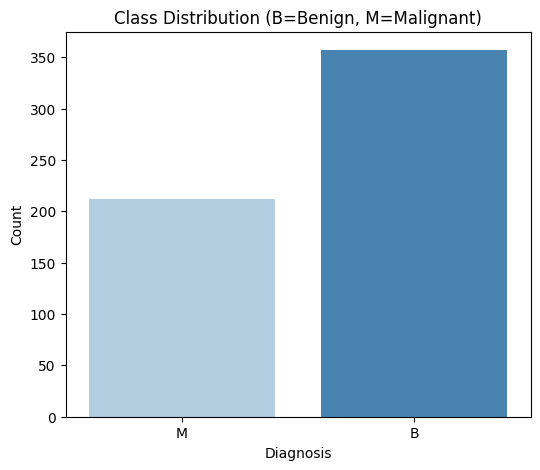

In [184]:
plt.figure(figsize=(6, 5))
sns.countplot(x=df_eda[TARGET_COLUMN], hue=df_eda[TARGET_COLUMN], palette="Blues", legend=False)
plt.title("Class Distribution (B=Benign, M=Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

Feature Distributions (Histograms)

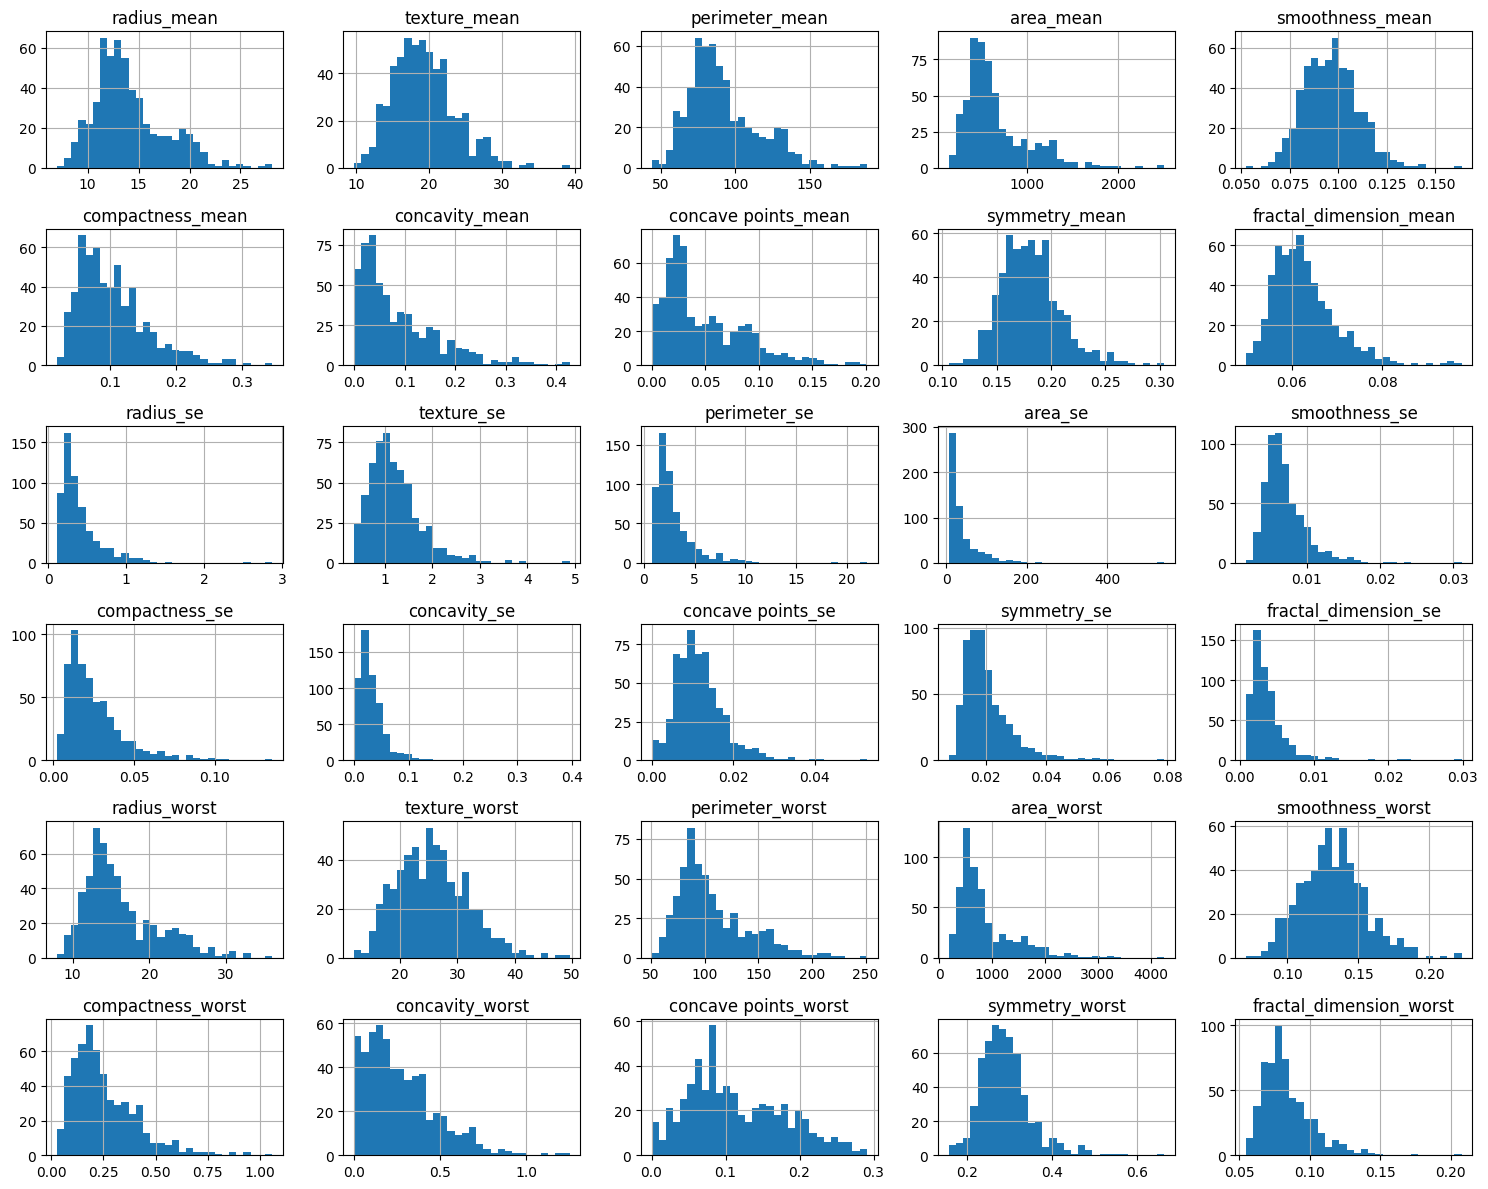

In [198]:
num_cols = df.select_dtypes(include=['float64']).columns
df[num_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

Correlation Heatmap

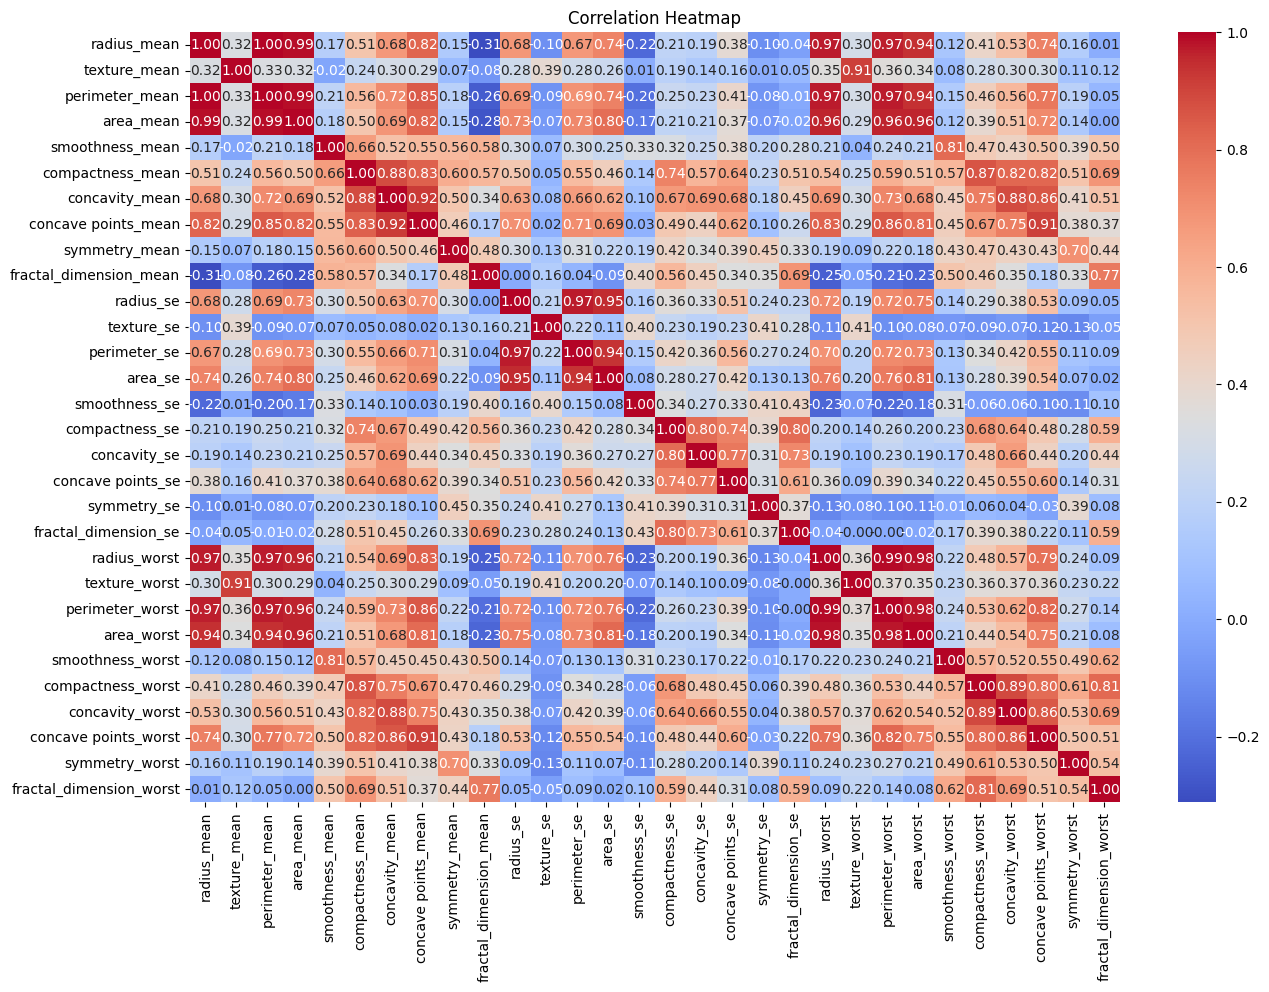

In [186]:
plt.figure(figsize=(15, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 3.TRAIN/TEST SPLIT




In [187]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("\nPreprocessing and Splitting Complete")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}\n")


Preprocessing and Splitting Complete
Training set shape: (455, 30)
Test set shape: (114, 30)



# 4. Train the following models:
• Decision

• AdaBoost

• Gradient Boosting

• XGBoost

• Random Forest

• Stacking Classifier (SVM + Na¨ıve Bayes + Decision Tree)

In [188]:
cv_results = {} # This should be defined before the function

def train_and_evaluate_model(model, param_grid, model_name, X_train, y_train, X_test, y_test, feature_names):


    print(f" Training and Evaluating: {model_name} ")

    # MODIFICATION: Define multiple scoring metrics and tell GridSearchCV to refit by accuracy
    scoring_metrics = ['accuracy', 'f1_weighted']
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring=scoring_metrics,
        refit='accuracy', # The model will be refit on the best 'accuracy' score
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    print(f" Best Hyperparameters found: {grid_search.best_params_}")


    print("\n Top Hyperparameter Trials (sorted by Accuracy) ")
    results_df = pd.DataFrame(grid_search.cv_results_)

    # Select only the columns we need for the table
    param_cols = [col for col in results_df.columns if col.startswith('param_')]
    metric_cols = ['mean_test_accuracy', 'mean_test_f1_weighted']

    # Create a cleaner table for display
    trials_table = results_df[param_cols + metric_cols].copy()

    # Clean up column names
    trials_table.columns = [c.replace('param_', '') for c in trials_table.columns]
    trials_table.rename(columns={'mean_test_accuracy': 'Accuracy', 'mean_test_f1_weighted': 'F1_score'}, inplace=True)

    # Print the top 10 best performing combinations
    print(trials_table.sort_values(by='Accuracy', ascending=False).round(4).head(10))


    print(f"\n Best 5-Fold CV Accuracy (from the search): {grid_search.best_score_:.4f}")

    # Store the cross-validation scores for the final summary table
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[model_name] = cv_scores

    # Evaluate the final model on the test set
    y_pred = best_model.predict(X_test)
    print(f"Final Test Set Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Evaluation Metrics for {model_name}', fontsize=16)
    ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
    axes[1].set_title('ROC Curve')
    plt.show()

    if hasattr(best_model, 'feature_importances_'):
        feature_imp = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=feature_imp, y=feature_imp.index)
        plt.title(f"Top 10 Feature Importances for {model_name}")
        plt.xlabel("Feature Importance Score")
        plt.ylabel("Features")
        plt.show()



# Decision Tree

 Training and Evaluating: Decision Tree 
 Best Hyperparameters found: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 5}

 Top Hyperparameter Trials (sorted by Accuracy) 
   criterion  max_depth  min_samples_split  Accuracy  F1_score
19   entropy          7                  5    0.9451    0.9452
22   entropy         10                  5    0.9451    0.9452
6       gini          7                  2    0.9429    0.9427
10      gini         10                  5    0.9385    0.9383
21   entropy         10                  2    0.9363    0.9365
18   entropy          7                  2    0.9363    0.9365
23   entropy         10                 10    0.9341    0.9342
16   entropy          5                  5    0.9341    0.9341
20   entropy          7                 10    0.9341    0.9342
15   entropy          5                  2    0.9341    0.9343

 Best 5-Fold CV Accuracy (from the search): 0.9451
Final Test Set Accuracy: 0.9474



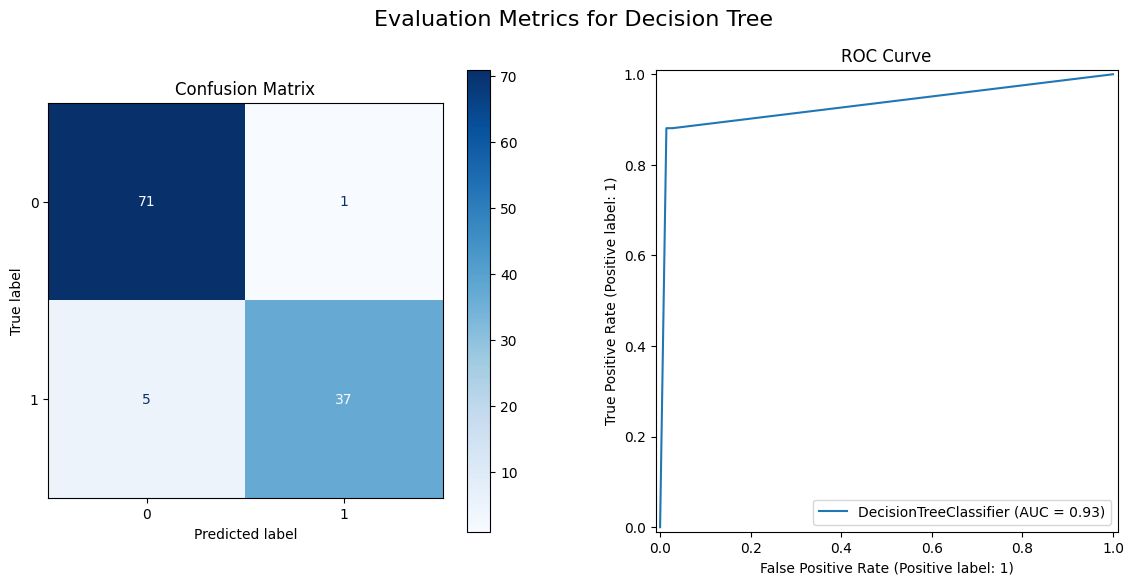

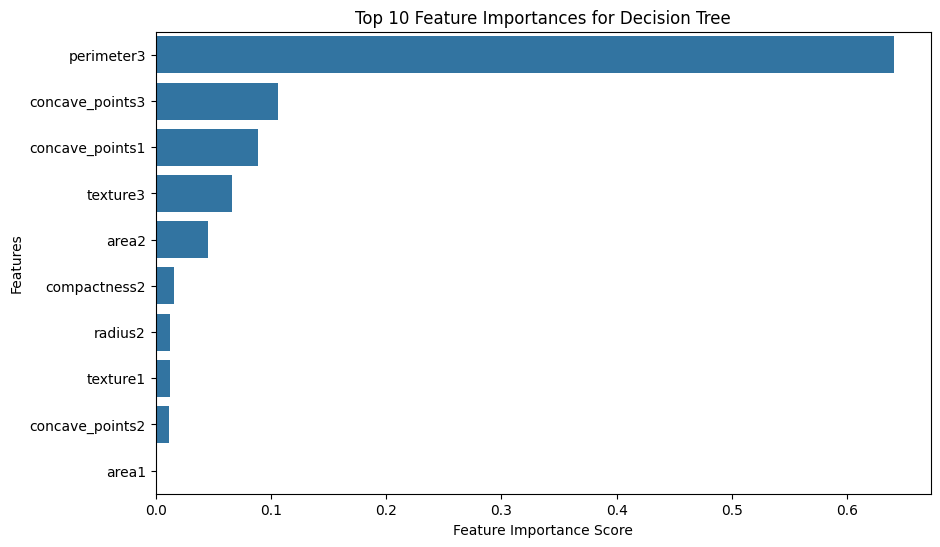

In [189]:

dt_model = DecisionTreeClassifier(random_state=42)
dt_param_grid = {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}
train_and_evaluate_model(dt_model, dt_param_grid, 'Decision Tree', X_train, y_train, X_test, y_test, feature_names)

#AdaBoost

 Training and Evaluating: AdaBoost 
 Best Hyperparameters found: {'learning_rate': 1.0, 'n_estimators': 200}

 Top Hyperparameter Trials (sorted by Accuracy) 
   learning_rate  n_estimators  Accuracy  F1_score
8           1.00           200    0.9648    0.9648
6           1.00            50    0.9626    0.9625
7           1.00           100    0.9604    0.9603
5           0.10           200    0.9516    0.9516
4           0.10           100    0.9516    0.9517
3           0.10            50    0.9495    0.9493
2           0.01           200    0.9319    0.9313
1           0.01           100    0.9253    0.9245
0           0.01            50    0.9231    0.9220

 Best 5-Fold CV Accuracy (from the search): 0.9648
Final Test Set Accuracy: 0.9737



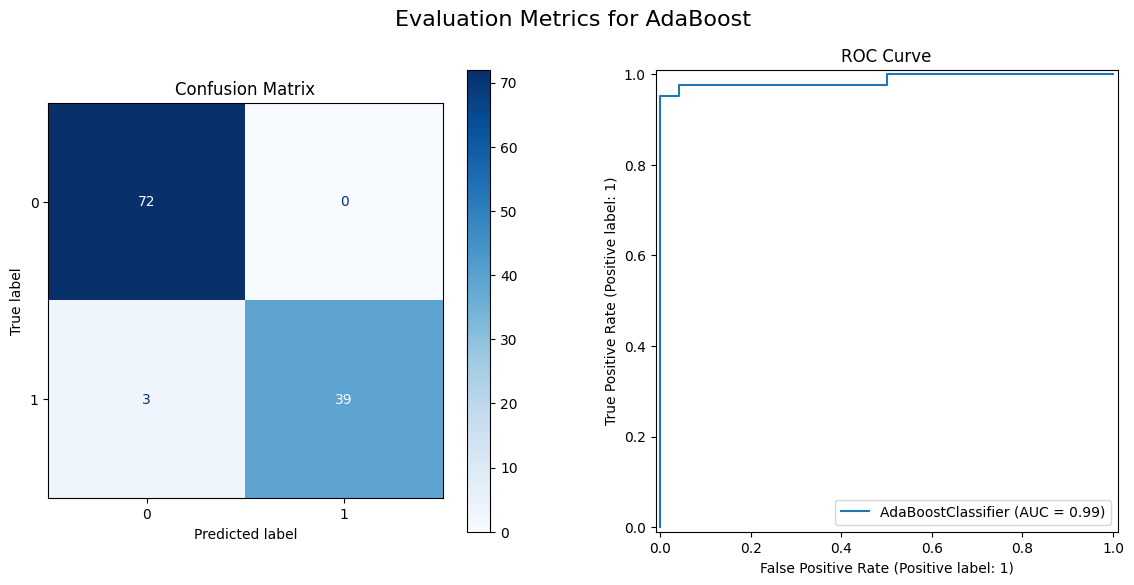

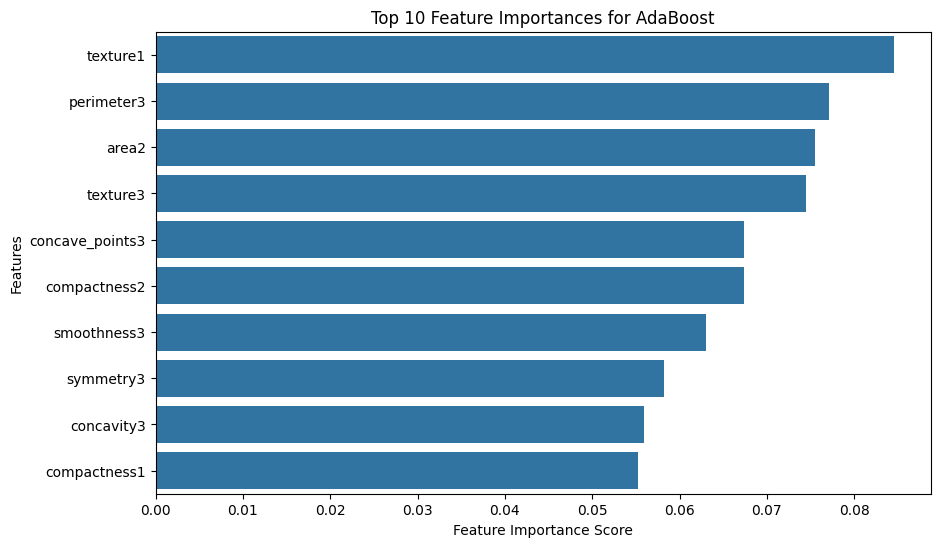

In [199]:

ada_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=42, algorithm='SAMME')
ada_param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}z
train_and_evaluate_model(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=42), {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}, 'AdaBoost', X_train, y_train, X_test, y_test, feature_names)

# Gradient Boosting

 Training and Evaluating: Gradient Boosting 
 Best Hyperparameters found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

 Top Hyperparameter Trials (sorted by Accuracy) 
   learning_rate  max_depth  n_estimators  Accuracy  F1_score
5           0.10          3           200    0.9538    0.9538
4           0.10          3           100    0.9538    0.9538
0           0.05          3           100    0.9516    0.9515
1           0.05          3           200    0.9516    0.9516
2           0.05          5           100    0.9407    0.9405
6           0.10          5           100    0.9297    0.9299
3           0.05          5           200    0.9275    0.9275
7           0.10          5           200    0.9209    0.9212

 Best 5-Fold CV Accuracy (from the search): 0.9538
Final Test Set Accuracy: 0.9649



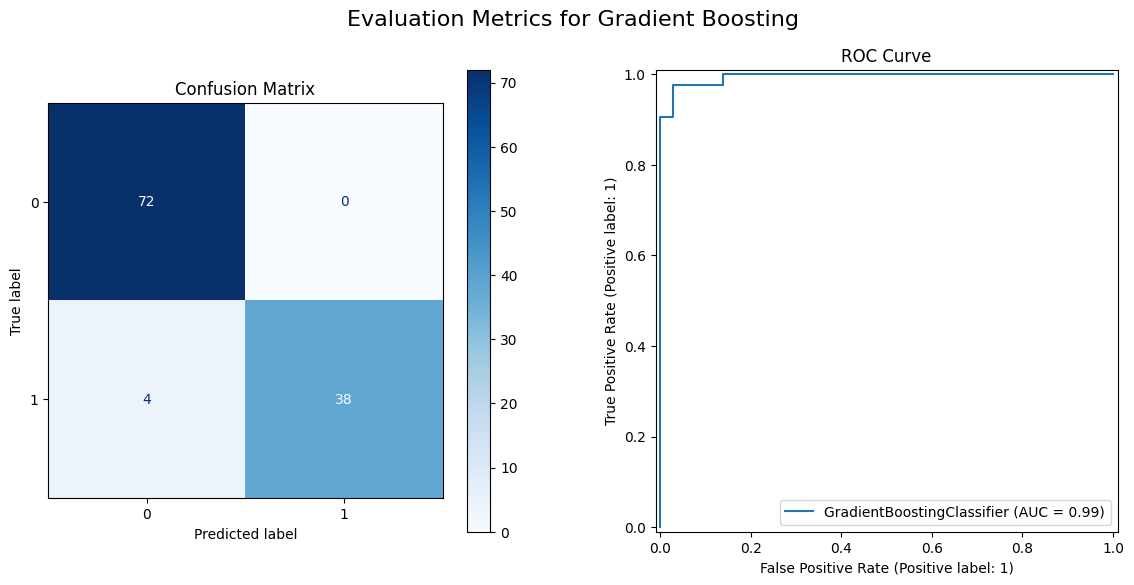

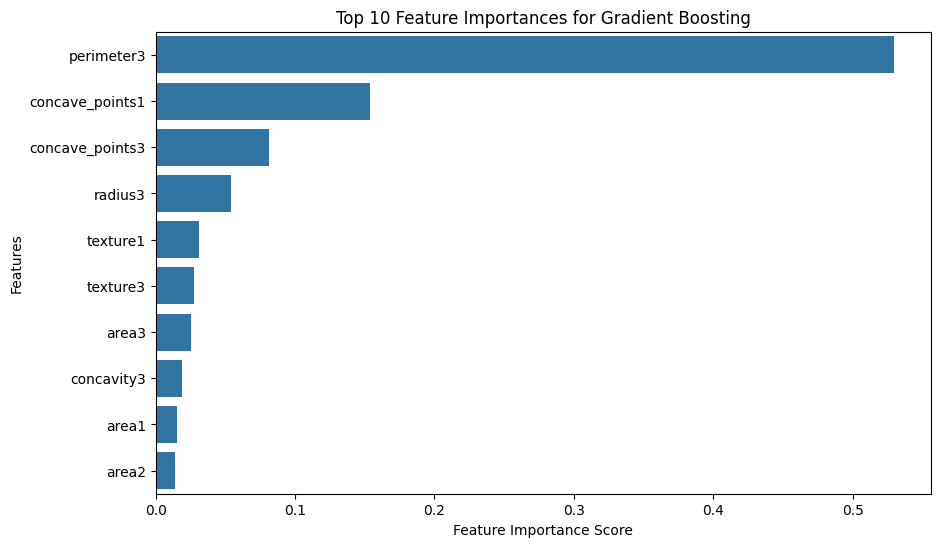

In [191]:

gb_model = GradientBoostingClassifier(random_state=42)
gb_param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
train_and_evaluate_model(gb_model, gb_param_grid, 'Gradient Boosting', X_train, y_train, X_test, y_test, feature_names)

#XGBoost

 Training and Evaluating: XGBoost 
 Best Hyperparameters found: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

 Top Hyperparameter Trials (sorted by Accuracy) 
   learning_rate  max_depth  n_estimators  Accuracy  F1_score
3           0.05          5           200    0.9648    0.9649
7           0.10          5           200    0.9626    0.9627
6           0.10          5           100    0.9626    0.9627
1           0.05          3           200    0.9582    0.9582
5           0.10          3           200    0.9582    0.9582
4           0.10          3           100    0.9582    0.9583
2           0.05          5           100    0.9538    0.9539
0           0.05          3           100    0.9538    0.9540

 Best 5-Fold CV Accuracy (from the search): 0.9648
Final Test Set Accuracy: 0.9649



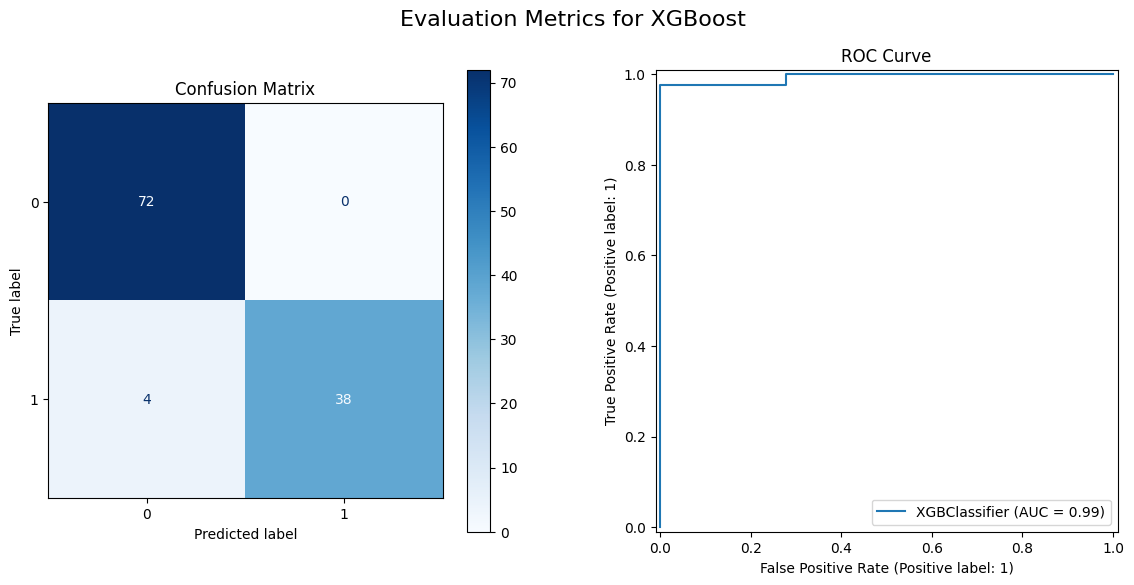

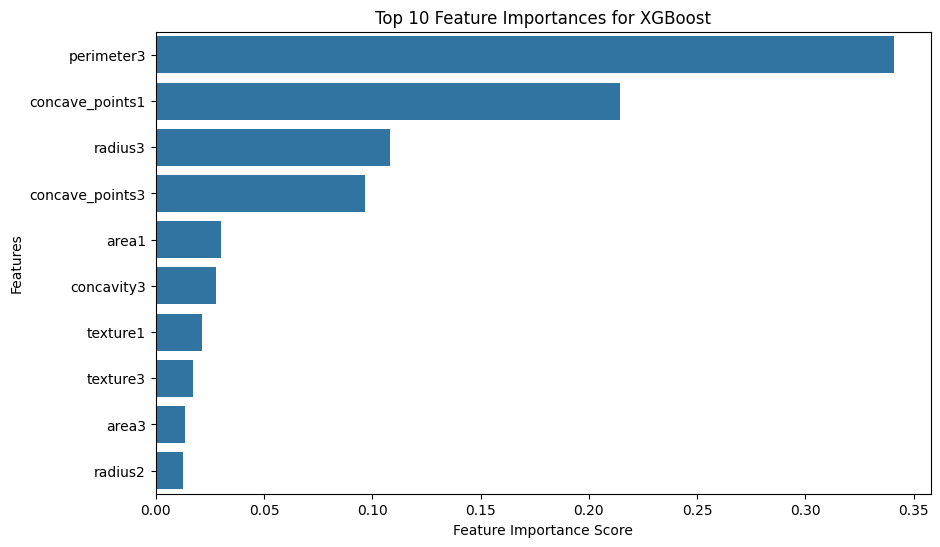

In [192]:

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
train_and_evaluate_model(xgb_model, xgb_param_grid, 'XGBoost', X_train, y_train, X_test, y_test, feature_names)

#Random Forest

 Training and Evaluating: Random Forest 
 Best Hyperparameters found: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}

 Top Hyperparameter Trials (sorted by Accuracy) 
   criterion max_depth  n_estimators  Accuracy  F1_score
2       gini        10           100    0.9626    0.9626
11   entropy      None           200    0.9626    0.9625
9    entropy        10           200    0.9626    0.9625
4       gini      None           100    0.9626    0.9626
3       gini        10           200    0.9582    0.9582
5       gini      None           200    0.9582    0.9582
0       gini         5           100    0.9560    0.9560
1       gini         5           200    0.9560    0.9559
8    entropy        10           100    0.9560    0.9559
6    entropy         5           100    0.9560    0.9559

 Best 5-Fold CV Accuracy (from the search): 0.9626
Final Test Set Accuracy: 0.9737



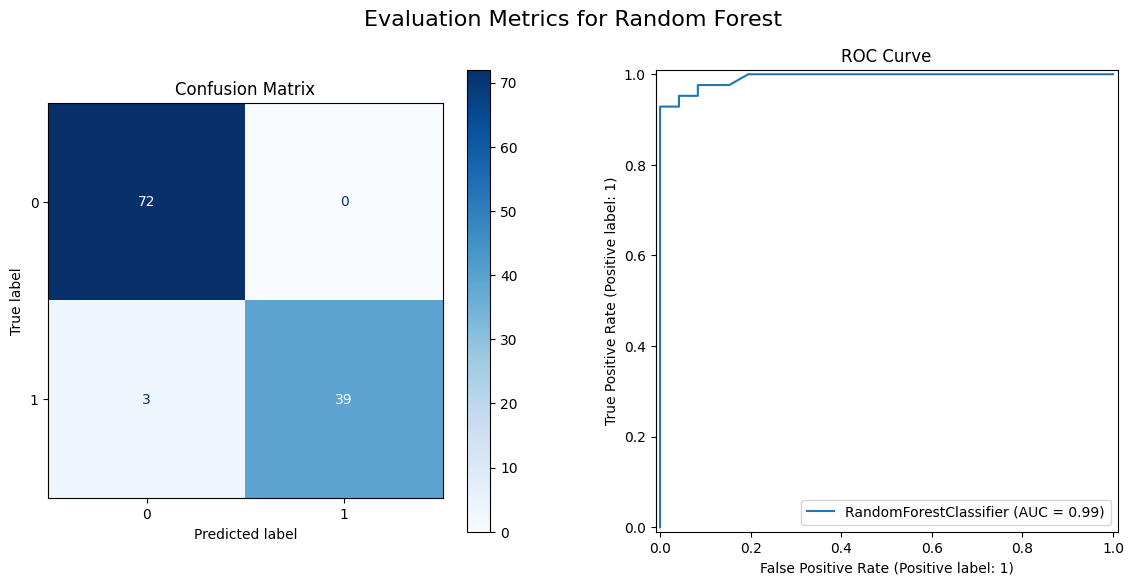

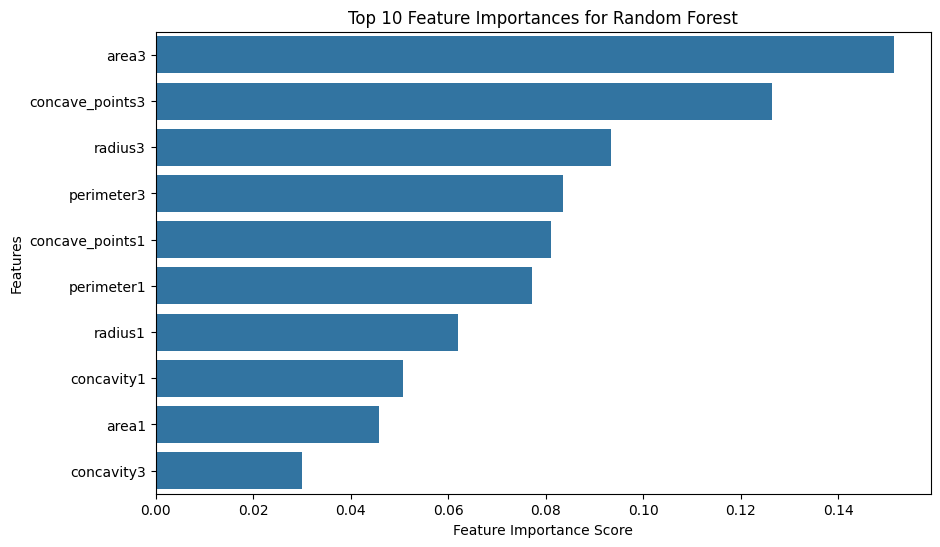

In [193]:

rf_model = RandomForestClassifier(random_state=42)
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'criterion': ['gini', 'entropy']}
train_and_evaluate_model(rf_model, rf_param_grid, 'Random Forest', X_train, y_train, X_test, y_test, feature_names)

#STACKING CLASSIFIER

Training and Evaluating Multiple Stacking Classifiers

 Evaluating: Stacked (SVM + Naive Bayes + Decision Tree -> Logistic Regression) 
  Average CV Accuracy: 0.9648


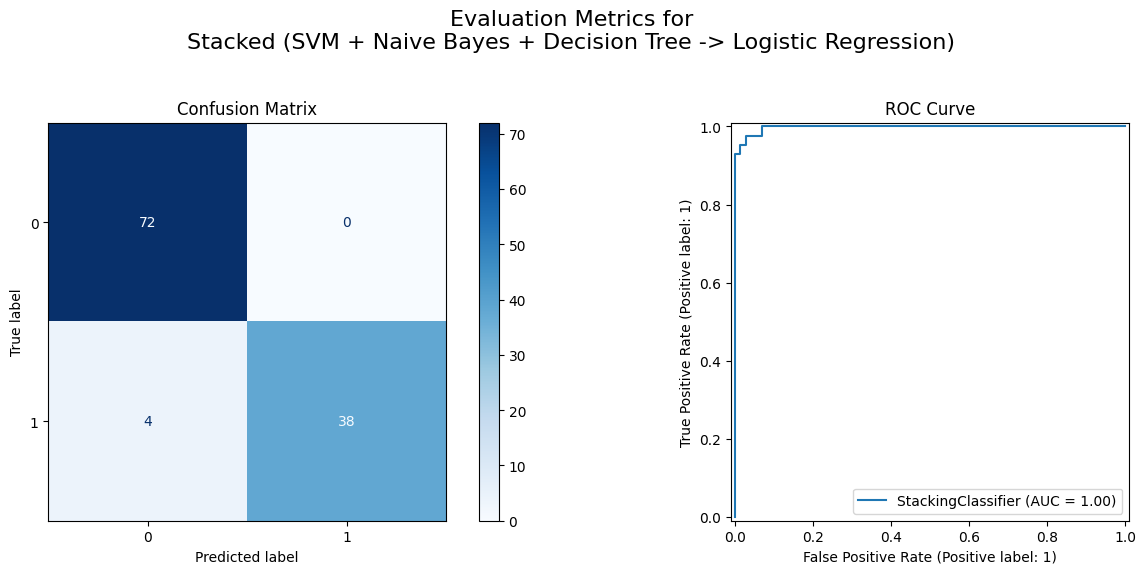

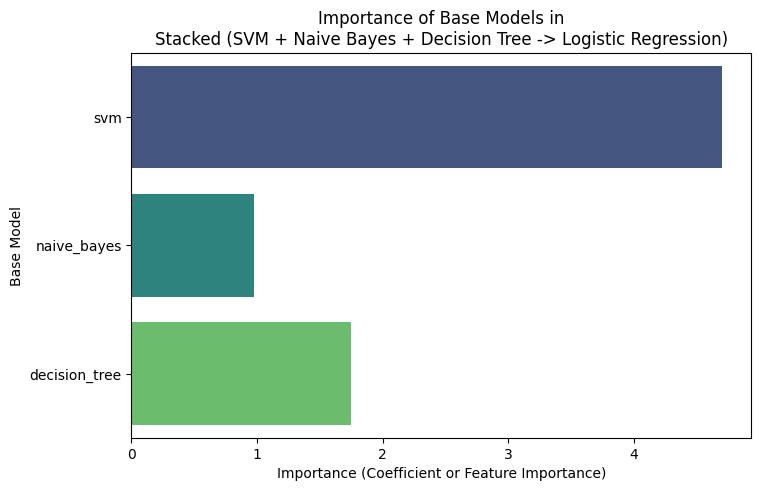


 Evaluating: Stacked (SVM + Naive Bayes + Decision Tree -> Random Forest) 
  Average CV Accuracy: 0.9670


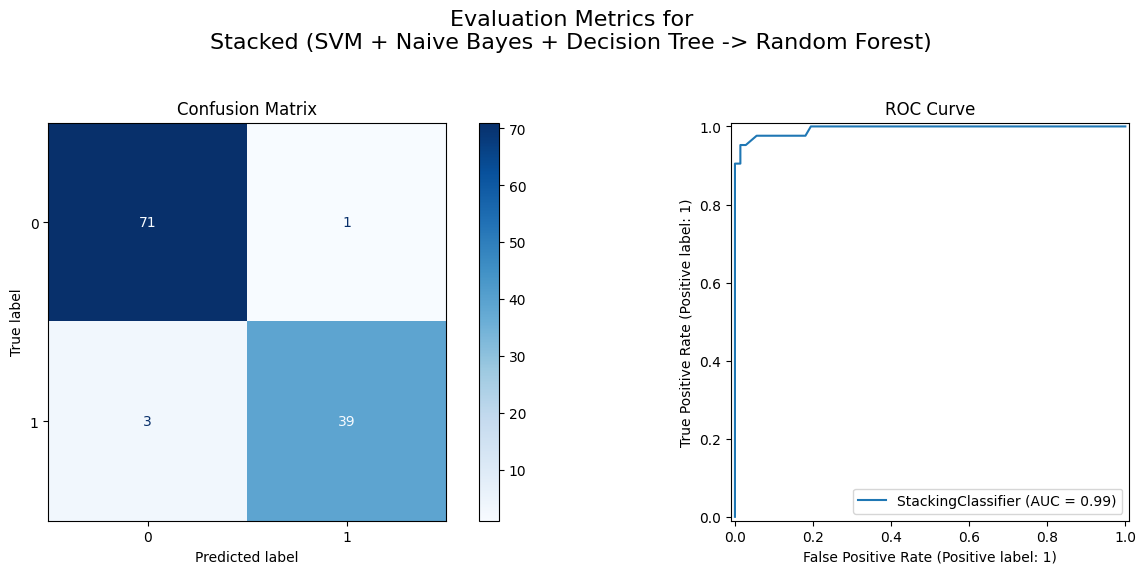

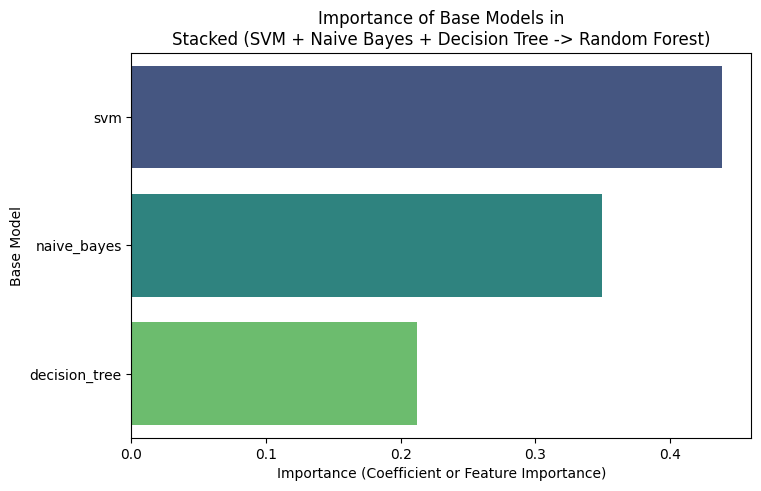


 Evaluating: Stacked (SVM + Decision Tree + KNN -> Logistic Regression) 
  Average CV Accuracy: 0.9736


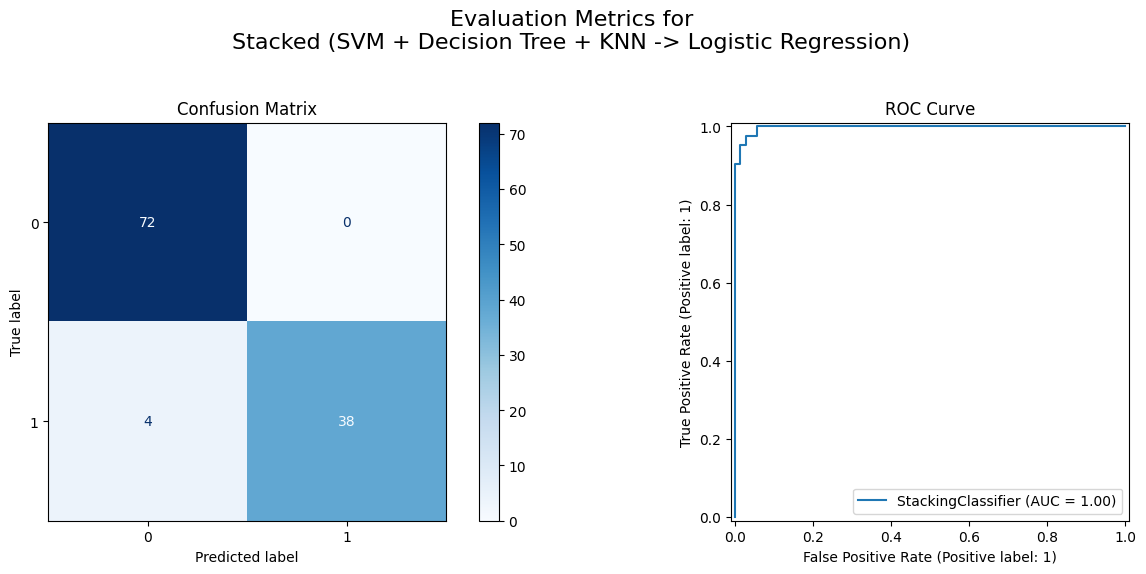

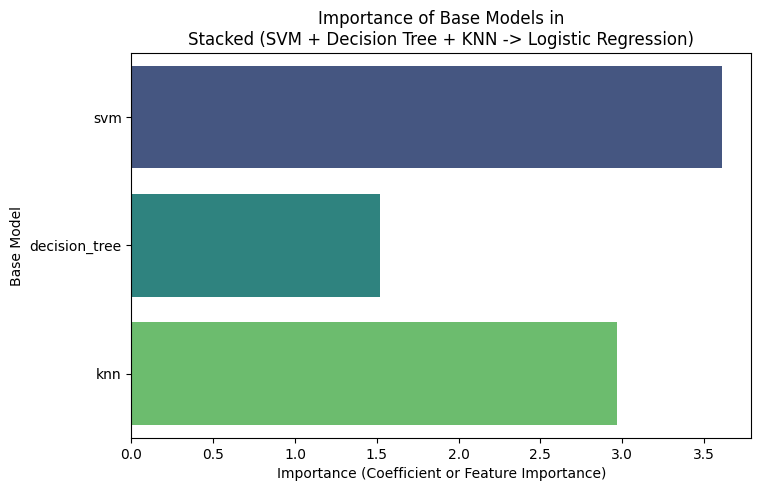


 Summary Table for Stacked Ensemble Models 
                         Base Models      Final Estimator CV Accuracy  \
0  SVM + Naive Bayes + Decision Tree  Logistic Regression      0.9648   
1  SVM + Naive Bayes + Decision Tree        Random Forest      0.9670   
2          SVM + Decision Tree + KNN  Logistic Regression      0.9736   

  Test Accuracy / F1  
0    0.9649 / 0.9645  
1    0.9649 / 0.9647  
2    0.9649 / 0.9645  


In [194]:
print(f"Training and Evaluating Multiple Stacking Classifiers")

# Define the building blocks for the ensembles
svm = ("svm", SVC(probability=True, random_state=42))
nb = ("naive_bayes", GaussianNB())
dt = ("decision_tree", DecisionTreeClassifier(random_state=42))
knn = ("knn", KNeighborsClassifier())

# Define the configurations to test
configs = [
    {
        "base_models": [svm, nb, dt],
        "final_estimator": LogisticRegression(random_state=42),
        "base_desc": "SVM + Naive Bayes + Decision Tree",
        "final_desc": "Logistic Regression"
    },
    {
        "base_models": [svm, nb, dt],
        "final_estimator": RandomForestClassifier(random_state=42),
        "base_desc": "SVM + Naive Bayes + Decision Tree",
        "final_desc": "Random Forest"
    },
    {
        "base_models": [svm, dt, knn],
        "final_estimator": LogisticRegression(random_state=42),
        "base_desc": "SVM + Decision Tree + KNN",
        "final_desc": "Logistic Regression"
    },
]

#  Loop through, evaluate each configuration, and generate plots

results = []
for config in configs:
    model_name_full = f"Stacked ({config['base_desc']} -> {config['final_desc']})"
    print(f"\n Evaluating: {model_name_full} ")

    clf = StackingClassifier(
        estimators=config["base_models"],
        final_estimator=config["final_estimator"],
        cv=5,
        n_jobs=-1
    )

    # Evaluate using 5-fold cross-validation

    cv_accuracy = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    mean_accuracy = np.mean(cv_accuracy)
    print(f"  Average CV Accuracy: {mean_accuracy:.4f}")

    # Fit the model to generate plots and test set scores
    clf.fit(X_train, y_train)



    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Evaluation Metrics for\n{model_name_full}', fontsize=16)
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=axes[1])
    axes[1].set_title('ROC Curve')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Plot Feature Importance for the Stacking Ensemble
    base_model_names = [name for name, _ in config["base_models"]]
    importances = []

    # Check if the final estimator has coefficients
    if hasattr(clf.final_estimator_, 'coef_'):
        #The coefficients tell us the importance of each base model's predictions
        importances = clf.final_estimator_.coef_[0]
    # Check if the final estimator has feature importances
    elif hasattr(clf.final_estimator_, 'feature_importances_'):
        importances = clf.final_estimator_.feature_importances_


    if len(importances) > 0:
        plt.figure(figsize=(8, 5))
        sns.barplot(x=importances, y=base_model_names, hue=base_model_names, palette="viridis", legend=False)
        plt.title(f"Importance of Base Models in\n{model_name_full}")
        plt.xlabel("Importance (Coefficient or Feature Importance)")
        plt.ylabel("Base Model")
        plt.show()


    # Append results for the summary table
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average="weighted")
    test_acc = accuracy_score(y_test, y_pred)
    results.append({
        "Base Models": config["base_desc"],
        "Final Estimator": config["final_desc"],
        "CV Accuracy": f"{mean_accuracy:.4f}",
        "Test Accuracy / F1": f"{test_acc:.4f} / {f1:.4f}"
    })


    if config['final_desc'] == "Logistic Regression" and "Naive Bayes" in config['base_desc']:
        cv_results['Stacked Model'] = cv_accuracy


#  Display the final summary table for the stacking models
print("\n Summary Table for Stacked Ensemble Models ")
stacked_results_df = pd.DataFrame(results)
print(stacked_results_df)

#FINAL SUMMARY TABLE


In [195]:

results_df = pd.DataFrame.from_dict(cv_results, orient='index', columns=[f'Fold {i+1}' for i in range(5)])
results_df['Average Accuracy'] = results_df.mean(axis=1)

print("\n Summary of 5-Fold Cross-Validation Accuracies")
print("\n",results_df.round(4))


 Summary of 5-Fold Cross-Validation Accuracies

                    Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Average Accuracy
Decision Tree       0.967   0.967  0.9341  0.9451  0.9121            0.9451
AdaBoost            0.989   1.000  0.9231  0.9780  0.9341            0.9648
Gradient Boosting   1.000   0.989  0.9231  0.9560  0.9011            0.9538
XGBoost             0.978   0.989  0.9341  1.0000  0.9231            0.9648
Random Forest       1.000   0.989  0.9341  0.9780  0.9121            0.9626
Stacked Model       0.978   1.000  0.9560  0.9560  0.9341            0.9648
